#**Data-Driven artificial Intelligence**

In [ ]:
import numpy as np #import numpy library and give it the alias 'np'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns



####**Installing Kaggle**

In [ ]:
!pip install kaggle --quiet #install kaggle

In [ ]:
!export kaggle_api_token=KGAT_ab6d4d9dabc7facc667cd3ed8c5c2e86

In [ ]:
!ls -lha kaggle.json

ls: cannot access 'kaggle.json': No such file or directory


In [ ]:
#upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nyashaamawoko","key":"bbaa48dd8e1742beafcb6a62ad2ac53b"}'}

In [ ]:
#Create kaggle directory
!mkdir ~/.kaggle

In [ ]:
#copy kaggle.json file into directory
!cp kaggle.json ~/.kaggle/

In [ ]:
ls -ltr ~/.kaggle

total 4
-rw-r--r-- 1 root root 69 Jan 14 14:11 kaggle.json


In [ ]:
!chmod 600 ~/.kaggle/kaggle.json

#**Data Collection and Preprocessing**

In [ ]:
!kaggle datasets list

ref                                                               title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                                          Heart Disease                                             3491  2025-12-11 15:29:14.327000           2114        273  1.0              
suvidyasonawane/student-academic-placement-performance-dataset    Student Academic Placement Performance Dataset           94469  2026-01-11 02:02:47.837000              0         26  1.0              
neurocipher/student-performance                                   Student Performance                                      49705  2025-12-12 12:06:28.973000           1261        157  1.0     

In [ ]:
!kaggle datasets list -s 'parkinsons.csv'

ref                                                      title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
souvikdbiswas/parkinsons-csv                             parkinsons.csv                                          15986  2025-11-29 10:09:03.240000              0          2  0.23529412       
gargmanas/parkinsonsdataset                              Parkinson's Disease Dataset                             15870  2021-04-29 08:15:50.707000           4621         78  0.7352941        
vunnathreddy/parkinsonscsv                               parkinsons.csv                                        2297378  2020-10-10 14:46:43.667000             97          0  0.11764706       
rahul7500/parkinsons-csv                

In [ ]:
!kaggle datasets download -d 'vunnathreddy/parkinsonscsv' -p ../data/kaggleDataSetForParkinsons
#downloading the dataset


Dataset URL: https://www.kaggle.com/datasets/vunnathreddy/parkinsonscsv
License(s): unknown
  0% 0.00/2.19M [00:00<?, ?B/s]
100% 2.19M/2.19M [00:00<00:00, 738MB/s]


In [ ]:
ls -ltr ../data/kaggleDataSetForParkinsons

total 2244
-rw-r--r-- 1 root root 2297378 Oct 10  2020 parkinsonscsv.zip


In [ ]:
!unzip ../data/kaggleDataSetForParkinsons/parkinsonscsv.zip -d ../data/kaggleDataSetForParkinsons

Archive:  ../data/kaggleDataSetForParkinsons/parkinsonscsv.zip
  inflating: ../data/kaggleDataSetForParkinsons/pd_speech_features.csv  


In [ ]:
!chmod 777 ../data/kaggleDataSetForParkinsons/pd_speech_features.csv

In [ ]:
import pandas as pd
#read the data
df = pd.read_csv('../data/kaggleDataSetForParkinsons/pd_speech_features.csv')
df.head()#call head without any arguments to see the first few rows

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,0,1,0.85247,0.71826,0.57227,240,239,0.008064,0.000087,0.00218,...,1.5620,2.6445,3.8686,4.2105,5.1221,4.4625,2.6202,3.0004,18.9405,1
1,0,1,0.76686,0.69481,0.53966,234,233,0.008258,0.000073,0.00195,...,1.5589,3.6107,23.5155,14.1962,11.0261,9.5082,6.5245,6.3431,45.1780,1
2,0,1,0.85083,0.67604,0.58982,232,231,0.008340,0.000060,0.00176,...,1.5643,2.3308,9.4959,10.7458,11.0177,4.8066,2.9199,3.1495,4.7666,1
3,1,0,0.41121,0.79672,0.59257,178,177,0.010858,0.000183,0.00419,...,3.7805,3.5664,5.2558,14.0403,4.2235,4.6857,4.8460,6.2650,4.0603,1
4,1,0,0.32790,0.79782,0.53028,236,235,0.008162,0.002669,0.00535,...,6.1727,5.8416,6.0805,5.7621,7.7817,11.6891,8.2103,5.0559,6.1164,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Columns: 755 entries, id to class
dtypes: float64(749), int64(6)
memory usage: 4.4 MB


####**defining the target(y) and features(x)**

In [ ]:
df.columns

Index(['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses', 'numPeriodsPulses',
       'meanPeriodPulses', 'stdDevPeriodPulses', 'locPctJitter',
       ...
       'tqwt_kurtosisValue_dec_28', 'tqwt_kurtosisValue_dec_29',
       'tqwt_kurtosisValue_dec_30', 'tqwt_kurtosisValue_dec_31',
       'tqwt_kurtosisValue_dec_32', 'tqwt_kurtosisValue_dec_33',
       'tqwt_kurtosisValue_dec_34', 'tqwt_kurtosisValue_dec_35',
       'tqwt_kurtosisValue_dec_36', 'class'],
      dtype='object', length=755)

In [ ]:
target = df['class']

In [ ]:
features = df[['id', 'gender', 'PPE', 'DFA', 'RPDE', 'numPulses',
               'numPeriodsPulses', 'meanPeriodPulses', 'stdDevPeriodPulses',
               'locPctJitter', 'tqwt_kurtosisValue_dec_28',
               'tqwt_kurtosisValue_dec_29', 'tqwt_kurtosisValue_dec_30',
               'tqwt_kurtosisValue_dec_31', 'tqwt_kurtosisValue_dec_32',
               'tqwt_kurtosisValue_dec_33', 'tqwt_kurtosisValue_dec_34',
               'tqwt_kurtosisValue_dec_35', 'tqwt_kurtosisValue_dec_36']]

####**Handling missing values**

In [ ]:
df.describe().T #shows the descriptive statistics. Data distribution

,count,mean,std,min,25%,50%,75%,max
id,756.0,125.500000,72.793721,0.000000,62.750000,125.500000,188.250000,251.00000
gender,756.0,0.515873,0.500079,0.000000,0.000000,1.000000,1.000000,1.00000
PPE,756.0,0.746284,0.169294,0.041551,0.762833,0.809655,0.834315,0.90766
DFA,756.0,0.700414,0.069718,0.543500,0.647053,0.700525,0.754985,0.85264
RPDE,756.0,0.489058,0.137442,0.154300,0.386537,0.484355,0.586515,0.87123
...,...,...,...,...,...,...,...,...
tqwt_kurtosisValue_dec_33,756.0,12.375335,16.341665,1.628700,3.114375,4.741450,12.201325,73.53220
tqwt_kurtosisValue_dec_34,756.0,14.799230,15.722502,1.861700,3.665925,6.725700,21.922050,62.00730
tqwt_kurtosisValue_dec_35,756.0,14.751559,14.432979,1.955900,3.741275,7.334250,22.495175,57.54430
tqwt_kurtosisValue_dec_36,756.0,31.481110,34.230991,2.364000,3.948750,10.637250,61.125325,156.42370


In [ ]:
df.isnull()

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36,class
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
751,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
752,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
753,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
754,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()#handling any missing values and outliers

,0
id,0
gender,0
PPE,0
DFA,0
RPDE,0
...,...
tqwt_kurtosisValue_dec_33,0
tqwt_kurtosisValue_dec_34,0
tqwt_kurtosisValue_dec_35,0
tqwt_kurtosisValue_dec_36,0


In [ ]:
#Identify the percentage of missing values
df.isnull().sum()/df.shape[0]*100
#there are no missing values in the dataset

,0
id,0.0
gender,0.0
PPE,0.0
DFA,0.0
RPDE,0.0
...,...
tqwt_kurtosisValue_dec_33,0.0
tqwt_kurtosisValue_dec_34,0.0
tqwt_kurtosisValue_dec_35,0.0
tqwt_kurtosisValue_dec_36,0.0


In [ ]:
#identify non_numeric columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns

#fill in missing values in numeric colunms only

for col in df.columns:
  if col not in non_numeric_cols:
    df[col] = df[col].fillna(df[col].mean())
    print(df[col])

Streaming output truncated to the last 5000 lines.
4      0.032471
         ...   
751    0.175620
752    0.131990
753    0.105040
754    0.112880
755    0.066633
Name: tqwt_energy_dec_17, Length: 756, dtype: float64
0      0.177280
1      0.242170
2      0.233100
3      0.025707
4      0.020096
         ...   
751    0.017223
752    0.023889
753    0.113530
754    0.094080
755    0.068338
Name: tqwt_energy_dec_18, Length: 756, dtype: float64
0      0.131220
1      0.167190
2      0.196840
3      0.015339
4      0.014891
         ...   
751    0.008914
752    0.010440
753    0.087050
754    0.043403
755    0.055585
Name: tqwt_energy_dec_19, Length: 756, dtype: float64
0      0.051588
1      0.038735
2      0.073713
3      0.018269
4      0.018550
         ...   
751    0.014600
752    0.013821
753    0.051901
754    0.027645
755    0.048040
Name: tqwt_energy_dec_20, Length: 756, dtype: float64
0      0.019785
1      0.014496
2      0.011667
3      0.030173
4      0.032853
         ... 

####**Splitting data into train and test data**

In [ ]:
df.to_csv('/cleaned parkinsons data.csv', index=False)

In [ ]:
#split the data into a training set and test data

x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [ ]:
from sklearn.model_selection import train_test_split #20% of the data is test data

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [ ]:
x_train

,id,gender,PPE,DFA,RPDE,numPulses,numPeriodsPulses,meanPeriodPulses,stdDevPeriodPulses,locPctJitter,...,tqwt_kurtosisValue_dec_27,tqwt_kurtosisValue_dec_28,tqwt_kurtosisValue_dec_29,tqwt_kurtosisValue_dec_30,tqwt_kurtosisValue_dec_31,tqwt_kurtosisValue_dec_32,tqwt_kurtosisValue_dec_33,tqwt_kurtosisValue_dec_34,tqwt_kurtosisValue_dec_35,tqwt_kurtosisValue_dec_36
361,120,0,0.46740,0.70349,0.51062,274,273,0.007061,0.001906,0.00232,...,3.2107,2.3252,1.9532,16.6878,16.8881,18.8021,24.5084,29.8984,33.6514,87.3800
262,87,1,0.53384,0.74257,0.76349,250,244,0.007239,0.001125,0.00739,...,2.0497,3.2079,7.6563,6.2605,6.0716,7.0607,8.1151,8.7994,8.1001,7.7602
92,30,0,0.78178,0.79967,0.43329,391,390,0.004934,0.000061,0.00189,...,11.1841,6.7295,3.8659,3.7486,3.0561,2.4128,2.4493,14.4983,28.1106,56.0278
479,159,0,0.83548,0.77247,0.62191,295,294,0.006558,0.000057,0.00085,...,2.2055,4.6407,4.0591,2.9987,2.8567,2.4912,2.6491,9.0749,10.0806,54.5370
496,165,1,0.71457,0.64467,0.37645,329,328,0.005875,0.000114,0.00102,...,14.8972,117.3940,47.1655,15.8310,8.0850,5.7487,4.6592,4.4614,3.8958,5.2395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,215,1,0.79028,0.76431,0.46302,192,191,0.010062,0.000109,0.00225,...,23.6906,19.7914,9.9797,2.2322,2.0386,2.1475,2.9612,4.0307,3.5016,10.4449
715,238,0,0.87911,0.67686,0.34910,405,404,0.004772,0.000037,0.00052,...,1.5321,1.5514,3.1759,4.3909,4.1059,4.5447,4.5917,8.4254,28.4708,74.1187
72,24,0,0.16874,0.71210,0.61151,166,165,0.011639,0.000158,0.00252,...,3.0974,2.7684,2.5700,3.5247,3.0191,2.9203,3.0888,3.4540,3.1089,2.8564
235,78,1,0.83537,0.65154,0.36501,237,236,0.008144,0.000063,0.00139,...,16.4637,7.0010,3.1073,1.8975,1.7472,2.9650,40.1108,46.8410,38.3727,89.7881


####**Scaling features**

In [ ]:
#i am going to do both scaling for my dataset to see which is more suitable for the model
#1) normalisation

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() #range will be the default between 1 and 0

x_train = scaler.fit_transform(x_train) #feature scale on the x trainig set and then transform it and replace the priginal test data

x_test = scaler.transform(x_test) #Avoid data leakage. this means that we dont leak informtion from our test set into the training set that we are going to use to train the model.
# the test set simulates new data that we have not seen before.


In [ ]:
x_train

array([[0.47808765, 0.        , 0.49168061, ..., 0.46614715, 0.57018191,
        0.55155363],
       [0.34661355, 1.        , 0.56839151, ..., 0.11534842, 0.11053025,
        0.03441434],
       [0.11952191, 0.        , 0.85466033, ..., 0.21010016, 0.47050644,
        0.34791767],
       ...,
       [0.09561753, 0.        , 0.14685103, ..., 0.02647409, 0.02074174,
        0.00256362],
       [0.31075697, 1.        , 0.91653475, ..., 0.74784024, 0.6551151 ,
        0.5671945 ],
       [0.04780876, 1.        , 0.91334809, ..., 0.09047545, 0.09913039,
        0.00729206]])

In [ ]:
#standardisation

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [ ]:
x_train

array([[-0.06562541, -1.00998361, -1.67945008, ...,  0.97119538,
         1.34219511,  1.62871265],
       [-0.52346427,  0.99011508, -1.2812105 , ..., -0.37752879,
        -0.46148031, -0.69317743],
       [-1.31427684, -1.00998361,  0.20493524, ..., -0.01323455,
         0.95106806,  0.71441291],
       ...,
       [-1.39752027, -1.00998361, -3.46961014, ..., -0.71922603,
        -0.8138109 , -0.83618313],
       [-0.64832941,  0.99011508,  0.52615226, ...,  2.05422747,
         1.67547337,  1.69893819],
       [-1.56400713,  0.99011508,  0.5096089 , ..., -0.4731585 ,
        -0.50621342, -0.81495303]])

In [ ]:
#need to find out which scaling feautres method to use. look into the lecture notes.


# **Model Selection and Training**

###**Naive Bayes Algorithm**

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(x_train, y_train)
predicted = model.predict(x_test)
print("Predicted Value: ", predicted)

Predicted Value:  [1 1 0 1 0 1 1 0 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1
 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 0 1 1 1 0 1 1 1 1 0 0 1
 1 1 1 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1
 0 1 1 1]


#**Prediction and Evaluation(Naive Bayes algorithm)**

####**Accuracy of Naive Bayes algorithm on the data set**

In [ ]:
from sklearn import metrics
accuracy = metrics.accuracy_score(y_test, predicted)
print("Accuracy (in %):", accuracy * 100)

Accuracy (in %): 80.92105263157895


In [ ]:

# this has given 80.9% accuracy



#**Visualisation (Naive Bayes algorithm)**

####**Confusion Matrix for Naive Bayes Classifier**

In [ ]:
#the following confusion matrix allows us to see where the model is making the correct predictions and where its not
cm = metrics.confusion_matrix(y_test, predicted)

In [ ]:
cm

array([[ 21,  13],
       [ 16, 102]])

Text(58.222222222222214, 0.5, 'Actual')

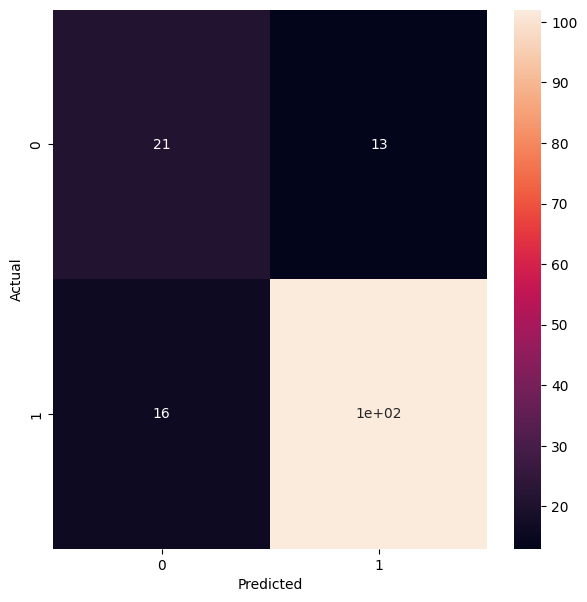

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(7,7))
sn.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [ ]:
#when the truth/Actual value was 0 and the predicted was 0,
#

##**Logistic Regression Algorithm**

In [ ]:
#the next step is to build the model
#i will make use of logistic regression to build the model


In [ ]:
from sklearn.linear_model import LogisticRegression
mylr = LogisticRegression() # i created a dynamic object tha would fit the model towards the training dataset
mylr.fit(x_train,y_train)
print("Logistic Regression model is built!")

Logistic Regression model is built!


#**Prediction and Evaluation(Logistic regression algorithm)**

In [ ]:
#now i need to predict the model using testing data set
model_pred=mylr.predict(x_test)#this is testing data of features


In [ ]:
#printing the predicted data
model_pred

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1])

####**Compare Actual Data and Predicted data of logistic regression model**

In [ ]:
print(y_test) #actual test data
print(model_pred) #predicted data

457    1
537    1
636    1
386    1
412    1
      ..
670    1
738    0
245    1
13     1
459    0
Name: class, Length: 152, dtype: int64
[1 1 1 1 1 1 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 0 0 1
 0 0 1 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 0
 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1 1
 0 1 1 1]


####**Accuracy(Logistic regression algorithm)**

In [ ]:
from sklearn import metrics
print("Accuracy of the model: ",metrics.accuracy_score(y_test, model_pred)*100, "%")

Accuracy of the model:  84.86842105263158 %


In [ ]:
#This model gives us 84% accuracy

#**Visualisation and insights(Logistic regression)**

####**Confusion Matrix for Logistic Regression**

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, model_pred)

In [ ]:
cm

array([[ 24,  10],
       [ 13, 105]])

Text(58.222222222222214, 0.5, 'Actual')

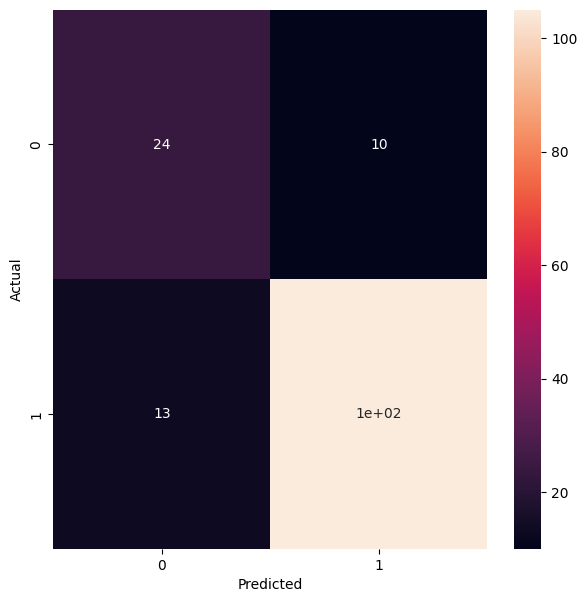

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sn
plt.figure(figsize=(7,7))
sn.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")